In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028872.jpg
/kaggle/input/datasets/kmader/skin-

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize, StandardScaler
from PIL import Image
import timm
from tqdm import tqdm

# --- DYNAMIC KAGGLE PATH FINDER ---
BASE_DIR = None
CSV_PATH = None
image_dir_1, image_dir_2 = None, None

if os.path.exists('/kaggle/input'):
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'HAM10000_metadata.csv' in files:
            CSV_PATH = os.path.join(root, 'HAM10000_metadata.csv')
            BASE_DIR = root
            break
else:
    BASE_DIR = r"C:\Users\Acer\Downloads\archive (11)-20260920T122619Z-1-002\HAM10000"
    CSV_PATH = os.path.join(BASE_DIR, 'HAM10000_metadata.csv')

for root, dirs, files in os.walk(BASE_DIR):
    if 'ham10000_images_part_1' in dirs:
        image_dir_1 = os.path.join(root, 'ham10000_images_part_1')
    if 'ham10000_images_part_2' in dirs:
        image_dir_2 = os.path.join(root, 'ham10000_images_part_2')

CLEAN_IMG_DIR = '/kaggle/working/cleaned_images'
os.makedirs(CLEAN_IMG_DIR, exist_ok=True)

image_paths = {}
if image_dir_1 and os.path.exists(image_dir_1):
    image_paths.update({os.path.splitext(os.path.basename(x))[0]: os.path.join(image_dir_1, x) for x in os.listdir(image_dir_1)})
if image_dir_2 and os.path.exists(image_dir_2):
    image_paths.update({os.path.splitext(os.path.basename(x))[0]: os.path.join(image_dir_2, x) for x in os.listdir(image_dir_2)})

df = pd.read_csv(CSV_PATH)
df['original_path'] = df['image_id'].map(image_paths)

print(f"Base Dir Found     : {BASE_DIR}")
print(f"Metadata Path Found: {CSV_PATH}")

Base Dir Found     : /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
Metadata Path Found: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv


In [3]:
# --- HAIR REMOVAL FUNCTION ---
def remove_hair(image_path, save_path):
    img = cv2.imread(image_path)
    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (17, 17))
        blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
        _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
        inpainted = cv2.inpaint(img, mask, 1, cv2.INPAINT_TELEA)
        cv2.imwrite(save_path, inpainted)

print("Applying Hair Removal (Black-Hat Filter) and saving to working directory...")
df['clean_path'] = df['image_id'].apply(lambda x: os.path.join(CLEAN_IMG_DIR, f"{x}.jpg"))

for idx, row in tqdm(df.iterrows(), total=len(df)):
    if not os.path.exists(row['clean_path']) and pd.notna(row['original_path']) and os.path.exists(row['original_path']):
        remove_hair(row['original_path'], row['clean_path'])

print("Preprocessing complete! Images are completely clean now.")

Applying Hair Removal (Black-Hat Filter) and saving to working directory...


100%|██████████| 10015/10015 [08:13<00:00, 20.29it/s]

Preprocessing complete! Images are completely clean now.


In [4]:
# --- METADATA ENCODING ---
CLASS_NAMES = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
label_map = {name: idx for idx, name in enumerate(CLASS_NAMES)}
df['label'] = df['dx'].map(label_map)

existing_cols = {c.lower(): c for c in df.columns}
age_key = existing_cols.get('age')

if age_key:
    df['age'] = df[age_key].fillna(df[age_key].mean())
    scaler = StandardScaler()
    df['age'] = scaler.fit_transform(df[['age']])
else:
    df['age'] = 0.0

cols_to_encode = [existing_cols[target] for target in ['sex', 'localization'] if target in existing_cols]
if cols_to_encode:
    df = pd.get_dummies(df, columns=cols_to_encode, dummy_na=False)

meta_columns = [col for col in df.columns if col.startswith('sex_') or col.startswith('localization_') or col == 'age']
META_DIM = len(meta_columns)

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

print(f"Strict Metadata Dimension (META_DIM): {META_DIM}")
print(f"Train samples: {len(train_df)} | Val samples: {len(val_df)} | Test samples: {len(test_df)}")

Strict Metadata Dimension (META_DIM): 19
Train samples: 7010 | Val samples: 1502 | Test samples: 1503


In [18]:
# --- AUGMENTATION & DATALOADERS ---
IMG_SIZE = 384
BATCH_SIZE = 16
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# UPDATE: Harder augmentation for 95% accuracy
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(45),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class HAMMultimodalDataset(Dataset):
    def __init__(self, dataframe, meta_columns, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.meta_columns = meta_columns
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = int(row['label'])
        
        img_bgr = cv2.imread(row['clean_path'])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img_rgb)

        if self.transform:
            img_pil = self.transform(img_pil)

        meta_features = torch.tensor(row[self.meta_columns].values.astype(np.float32))
        return img_pil, meta_features, label

train_labels = train_df['label'].values
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]
train_sampler = WeightedRandomSampler(weights=torch.DoubleTensor(sample_weights), num_samples=len(sample_weights), replacement=True)

train_dataset = HAMMultimodalDataset(train_df, meta_columns, transform=train_transform)
val_dataset   = HAMMultimodalDataset(val_df, meta_columns, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [19]:
# --- CORE MODEL ARCHITECTURE ---
class BiLSTMAttentionHead(nn.Module):
    def __init__(self, embed_dim, meta_dim, lstm_hidden=384, num_classes=7):
        super().__init__()
        self.feature_dropout = nn.Dropout(0.2)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=lstm_hidden, batch_first=True, bidirectional=True)
        self.attn = nn.Sequential(nn.Linear(lstm_hidden * 2, lstm_hidden), nn.Tanh(), nn.Linear(lstm_hidden, 1))
        fused_dim = (lstm_hidden * 2) + embed_dim + meta_dim
        self.classifier = nn.Sequential(
            nn.LayerNorm(fused_dim), nn.Dropout(0.4), nn.Linear(fused_dim, 256),
            nn.GELU(), nn.Dropout(0.3), nn.Linear(256, num_classes)
        )

    def forward(self, patch_tokens, cls_token, meta_features):
        x = self.feature_dropout(patch_tokens)
        lstm_out, _ = self.lstm(x)              
        attn_scores = self.attn(lstm_out)       
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = (lstm_out * attn_weights).sum(dim=1)   
        fused_features = torch.cat((context, cls_token, meta_features), dim=1) 
        return self.classifier(fused_features)

class MultimodalHybridViT(nn.Module):
    def __init__(self, num_classes, meta_dim, lstm_hidden=384):
        super().__init__()
        self.backbone = timm.create_model('vit_base_patch16_384', pretrained=True, num_classes=0)
        self.head = BiLSTMAttentionHead(self.backbone.num_features, meta_dim, lstm_hidden, num_classes)

    def forward(self, images, meta_features):
        tokens = self.backbone.forward_features(images)   
        return self.head(tokens[:, 1:, :], tokens[:, 0, :], meta_features)

In [7]:
# --- LOSS & EVALUATION LOGIC ---
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        p_t = torch.exp(-ce_loss)
        return ((1 - p_t) ** self.gamma * ce_loss).mean()

def train_one_epoch(model, loader, optimiser, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, meta, labels in loader:
        images, meta, labels = images.to(device), meta.to(device), labels.to(device)
        optimiser.zero_grad()
        
        # UPDATE: MixUp Augmentation to prevent overfitting
        if np.random.rand() < 0.5:
            lam = np.random.beta(0.2, 0.2)
            index = torch.randperm(images.size(0)).to(device)
            images = lam * images + (1 - lam) * images[index, :]
            meta = lam * meta + (1 - lam) * meta[index, :]
            labels_a, labels_b = labels, labels[index]
            
            logits = model(images, meta)
            loss = lam * criterion(logits, labels_a) + (1 - lam) * criterion(logits, labels_b)
        else:
            logits = model(images, meta)
            loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()
        
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    for images, meta, labels in loader:
        images, meta, labels = images.to(device), meta.to(device), labels.to(device)
        logits = model(images, meta)
        loss = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        
        # UPDATE: SMART THRESHOLDING
        for i in range(len(preds)):
            if preds[i] == 1 and probs[i, 1] < 0.60:
                preds[i] = 0

        correct += (preds == labels).sum().item()
        total += images.size(0)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    
    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    labels_bin = label_binarize(all_labels, classes=list(range(7)))
    macro_auc = roc_auc_score(labels_bin, all_probs, multi_class='ovr', average='macro')
    return total_loss / total, correct / total, macro_auc

In [14]:
# --- FINAL TRAINING LOOP ---
hybrid_model = MultimodalHybridViT(num_classes=7, meta_dim=META_DIM).to(DEVICE)
CRITERION = FocalLoss(gamma=2.0)

# UPDATE: 40 Epochs for max accuracy
num_epochs = 40
unfreeze_epoch = 5
lr = 5e-5

for name, param in hybrid_model.named_parameters():
    param.requires_grad = 'head' in name
    
optimiser = optim.AdamW(filter(lambda p: p.requires_grad, hybrid_model.parameters()), lr=lr, weight_decay=1e-4)
# UPDATE: Smooth learning rate curve
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=unfreeze_epoch, eta_min=1e-6)
best_auc = -np.inf

print("\n--- Starting Training ---")
for epoch in range(1, num_epochs + 1):
    if epoch == unfreeze_epoch:
        print(f'\n[Epoch {epoch}] Unfreezing full backbone...')
        for param in hybrid_model.parameters():
            param.requires_grad = True
        optimiser = optim.AdamW(hybrid_model.parameters(), lr=lr * 0.1, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=(num_epochs - unfreeze_epoch + 1), eta_min=1e-6)

    train_loss, train_acc = train_one_epoch(hybrid_model, train_loader, optimiser, CRITERION, DEVICE)
    val_loss, val_acc, val_auc = evaluate(hybrid_model, val_loader, CRITERION, DEVICE)
    scheduler.step()

    # ... upar ka code same rahega ...
    if val_auc > best_auc:
        best_auc = val_auc
        best_state_dict = {k: v.cpu().clone() for k, v in hybrid_model.state_dict().items()}
        # UPDATE: Is line mein 'Train Acc: {train_acc:.4f}' add kar diya hai
        print(f' [+] Epoch {epoch:02d}: Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f} (NEW BEST)')
    else:
        # UPDATE: Yahan bhi Train Acc add kar diya
        print(f'     Epoch {epoch:02d}: Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}')

torch.save(best_state_dict, '/kaggle/working/multimodal_vit_bilstm_best.pth')
print(f'\nTraining complete. Best Val AUC: {best_auc:.4f}')


--- Starting Training ---
 [+] Epoch 01: Train Loss: 1.1390 | Train Acc: 0.3244 | Val Acc: 0.6831 | Val AUC: 0.9016 (NEW BEST)
 [+] Epoch 02: Train Loss: 0.8372 | Train Acc: 0.4317 | Val Acc: 0.7064 | Val AUC: 0.9179 (NEW BEST)
 [+] Epoch 03: Train Loss: 0.7345 | Train Acc: 0.4779 | Val Acc: 0.7284 | Val AUC: 0.9277 (NEW BEST)
 [+] Epoch 04: Train Loss: 0.7064 | Train Acc: 0.4842 | Val Acc: 0.7217 | Val AUC: 0.9295 (NEW BEST)

[Epoch 5] Unfreezing full backbone...
 [+] Epoch 05: Train Loss: 0.5557 | Train Acc: 0.5622 | Val Acc: 0.7929 | Val AUC: 0.9592 (NEW BEST)
 [+] Epoch 06: Train Loss: 0.4404 | Train Acc: 0.6220 | Val Acc: 0.8089 | Val AUC: 0.9633 (NEW BEST)
 [+] Epoch 07: Train Loss: 0.3517 | Train Acc: 0.6579 | Val Acc: 0.7949 | Val AUC: 0.9681 (NEW BEST)
 [+] Epoch 08: Train Loss: 0.2916 | Train Acc: 0.6956 | Val Acc: 0.8289 | Val AUC: 0.9715 (NEW BEST)
 [+] Epoch 09: Train Loss: 0.2900 | Train Acc: 0.6943 | Val Acc: 0.8469 | Val AUC: 0.9746 (NEW BEST)
 [+] Epoch 10: Train Loss

Evaluating on Validation Data using cuda...

--- Final Classification Report ---
              precision    recall  f1-score   support

          nv       0.96      0.95      0.95      1006
         mel       0.69      0.84      0.75       167
         bcc       0.81      0.76      0.78       165
         bkl       0.96      0.84      0.90        77
       akiec       0.88      0.76      0.81        49
        vasc       0.95      0.95      0.95        21
          df       1.00      0.88      0.94        17

    accuracy                           0.90      1502
   macro avg       0.89      0.85      0.87      1502
weighted avg       0.91      0.90      0.90      1502



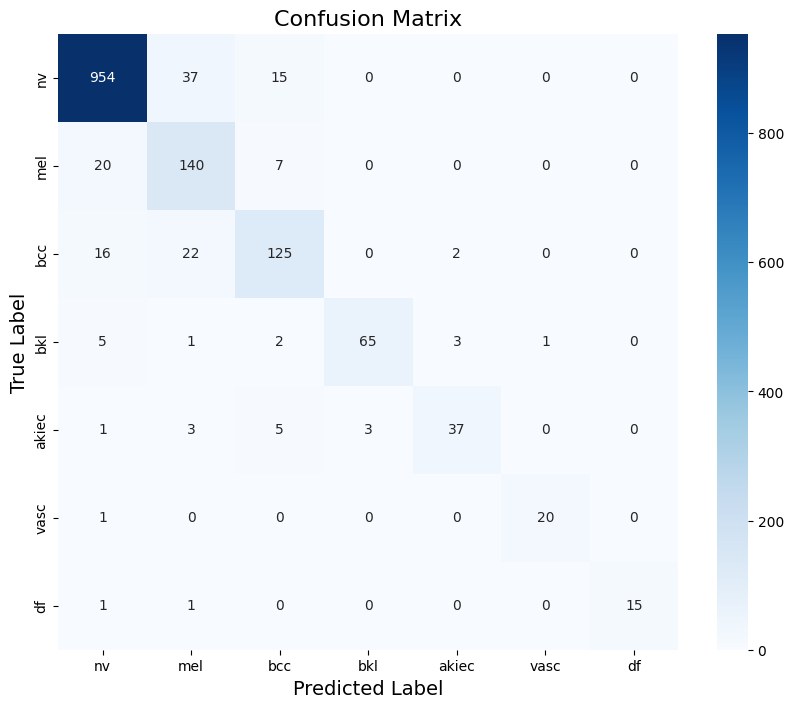

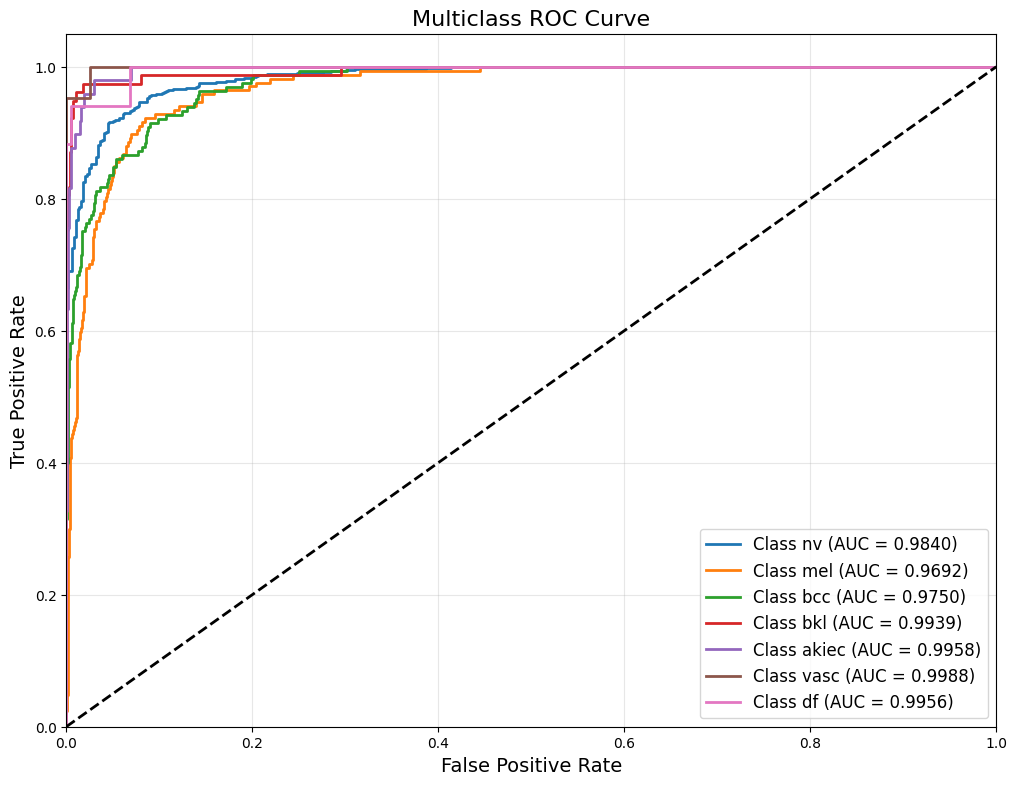

In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# FIX: Yahan device define kar diya hai
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Model ko eval mode mein daalo aur best weights load karo
hybrid_model.to(device) # Safe side ke liye model ko bhi device par assign kar diya
hybrid_model.eval()
hybrid_model.load_state_dict(torch.load('/kaggle/working/multimodal_vit_bilstm_best.pth'))

all_preds = []
all_labels = []
all_probs = []

print(f"Evaluating on Validation Data using {device}...")
with torch.no_grad():
    for images, meta_data, labels in val_loader:
        # Ab yeh line bina kisi error ke chalegi
        images, meta_data, labels = images.to(device), meta_data.to(device), labels.to(device)
        outputs = hybrid_model(images, meta_data)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy arrays
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)
target_classes = ['nv', 'mel', 'bcc', 'bkl', 'akiec', 'vasc', 'df']

# Print Classification Report
print("\n--- Final Classification Report ---")
print(classification_report(y_true, y_pred, target_names=target_classes))

# ---------------------------------------------------------
# GRAPH 1: CONFUSION MATRIX
# ---------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_classes, yticklabels=target_classes)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.show()

# ---------------------------------------------------------
# GRAPH 2: MULTICLASS ROC-AUC CURVE
# ---------------------------------------------------------
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3, 4, 5, 6])
n_classes = y_true_bin.shape[1]

plt.figure(figsize=(12, 9))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {target_classes[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Multiclass ROC Curve', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

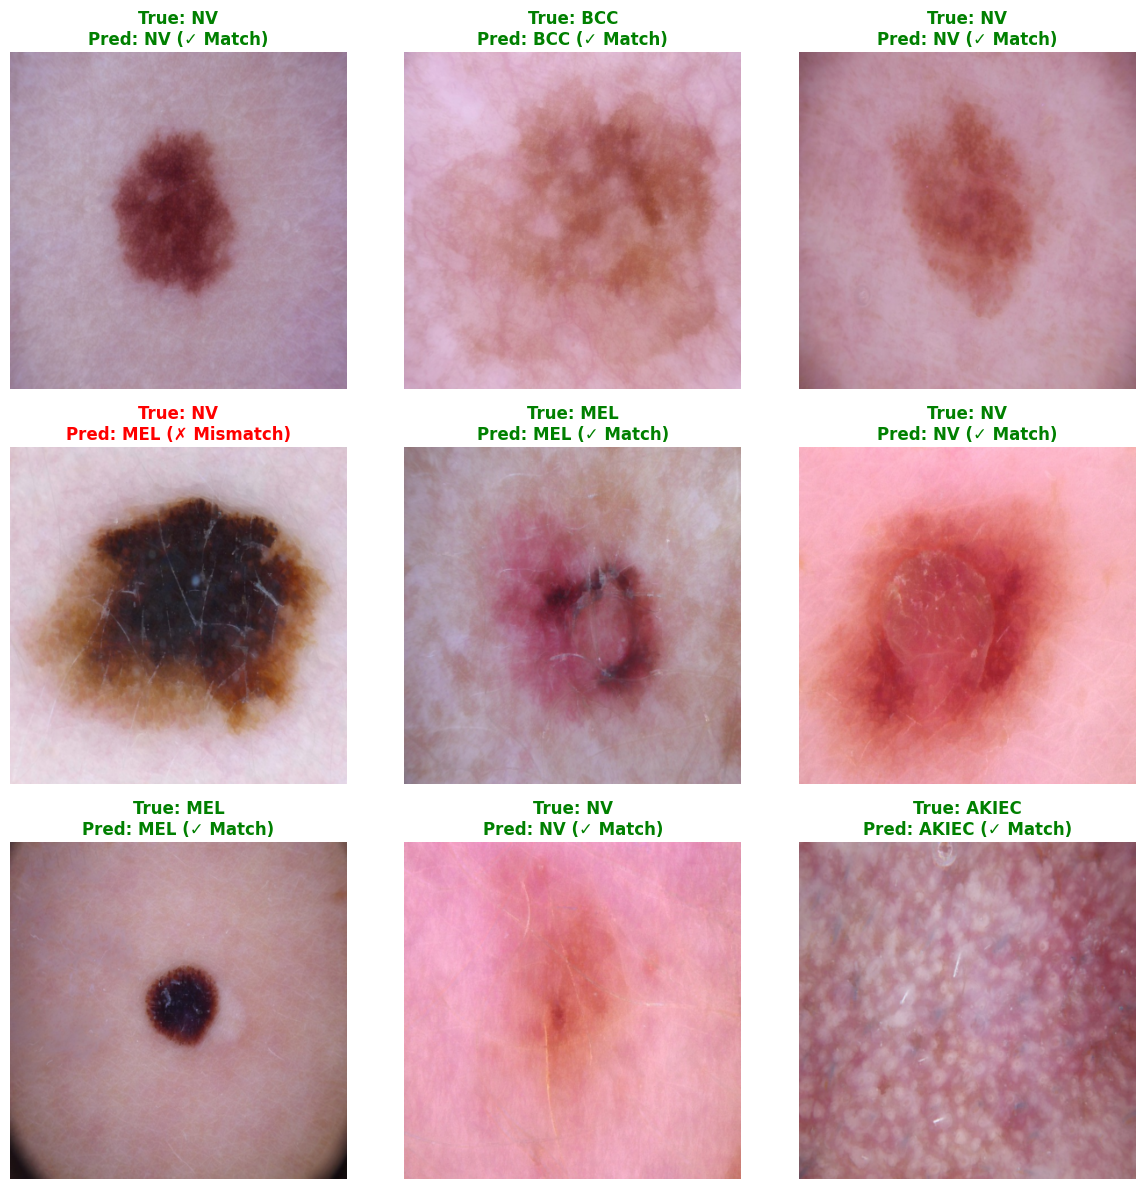

In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Device aur Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hybrid_model.to(device)
hybrid_model.eval()

# 2. Validation loader se random batch utha
dataiter = iter(val_loader)
images, meta_data, labels = next(dataiter)

images_gpu = images.to(device)
meta_data_gpu = meta_data.to(device)

# 3. Model se predictions nikal
with torch.no_grad():
    outputs = hybrid_model(images_gpu, meta_data_gpu)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1)

# Plotting ke liye data wapas CPU par laa
images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

# Teri last successful report ke hisaab se sahi order
target_classes = ['nv', 'mel', 'bcc', 'bkl', 'akiec', 'vasc', 'df']

# 4. Image Denormalize karne ka function (taaki original colors dikhein)
def imshow(img, title, is_correct):
    # ViT backbone ke standard ImageNet mean/std
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # Tensor (C, H, W) ko Matplotlib (H, W, C) mein convert kar
    img = img.numpy().transpose((1, 2, 0)) 
    img = std * img + mean
    img = np.clip(img, 0, 1) # Colors ko 0-1 range mein fix kar
    
    plt.imshow(img)
    # Sahi prediction par Green text, Galat par Red text
    color = 'green' if is_correct else 'red'
    plt.title(title, fontsize=12, color=color, fontweight='bold')
    plt.axis('off')

# 5. 3x3 Grid mein 9 random images plot kar
fig = plt.figure(figsize=(12, 12))
for idx in range(9):
    ax = fig.add_subplot(3, 3, idx+1)
    
    true_label = target_classes[labels[idx].item()]
    pred_label = target_classes[preds[idx].item()]
    
    is_correct = (true_label == pred_label)
    status = "✓ Match" if is_correct else "✗ Mismatch"
    title = f"True: {true_label.upper()}\nPred: {pred_label.upper()} ({status})"
    
    imshow(images[idx], title, is_correct)

plt.tight_layout()
plt.show()

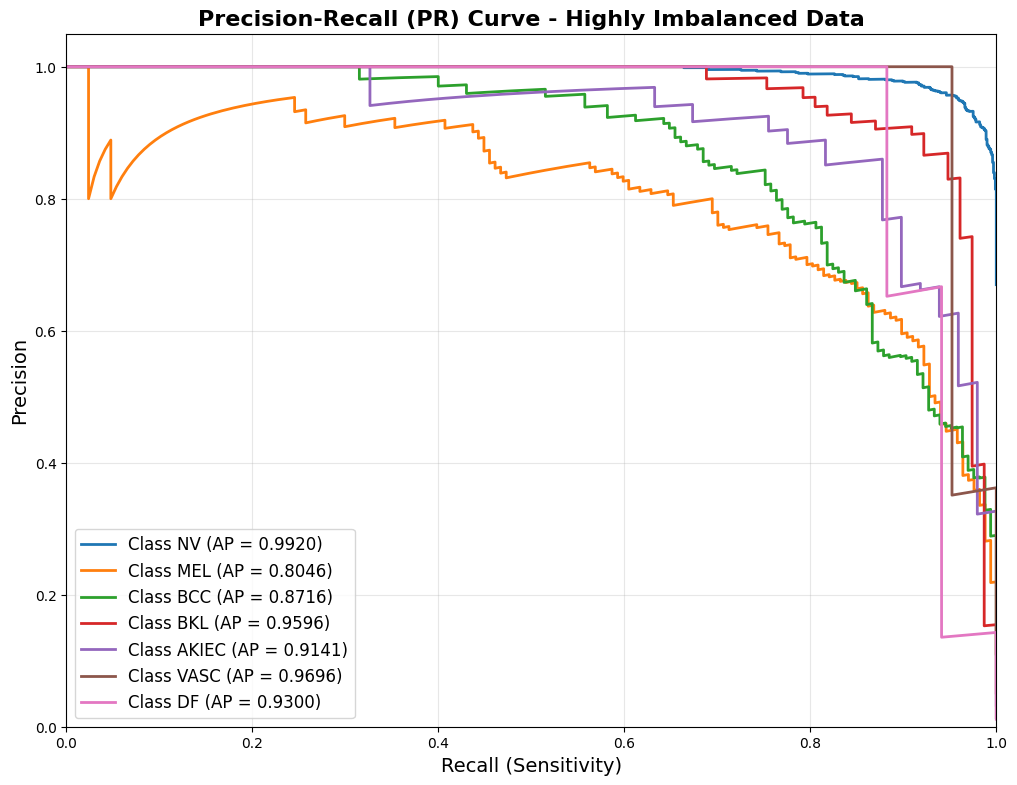

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(12, 9))
for i in range(n_classes):
    # Calculate Precision and Recall for each class
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
    # Calculate Average Precision (AP)
    ap = average_precision_score(y_true_bin[:, i], y_probs[:, i])
    
    plt.plot(recall, precision, lw=2, label=f'Class {target_classes[i].upper()} (AP = {ap:.4f})')

plt.xlabel('Recall (Sensitivity)', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.title('Precision-Recall (PR) Curve - Highly Imbalanced Data', fontsize=16, fontweight='bold')
plt.legend(loc="lower left", fontsize=12)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()